# 11 Advanced: FrameGraph + Spatial Types

This notebook combines notebooks 08 and 10: typed spatial quantities plus frame topology and edge resolvers.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd
from tal.frames import (
    FrameGraph,
    FrameGraphDrawOptions,
    draw_frame_graph,
    find_path,
)
from tal.spatial import (
    Acceleration,
    AngularAcceleration,
    AngularVelocity,
    LinearAcceleration,
    LinearVelocity,
    Pose,
    Position,
    Rotation,
    Velocity,
    get_edge_motion_class,
    get_frame_inertial_status,
)
from tal.utils.frame_ops import frame_ids, frame_retag

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Build a directed frame topology

The route `tool -> map` traverses several directed edges. Path direction matters.


In [2]:
with FrameGraph() as graph:
    world = graph.get_or_create_frame('world')
    base = graph.get_or_create_frame('base', parent=world)
    sensor = graph.get_or_create_frame('sensor', parent=base)
    tool = graph.get_or_create_frame('tool', parent=sensor)
    map_frame = graph.get_or_create_frame('map', parent=world)

    tool_to_map_path = find_path(tool, map_frame)

print('path nodes tool->map:', [node.id for node in tool_to_map_path.nodes])
for i, step in enumerate(tool_to_map_path.steps):
    direction = 'forward(parent->child)' if step.invert else 'reverse(child->parent)'
    print(f'step[{i}] edge=({step.parent.id}->{step.child.id}) traversal={direction}')


path nodes tool->map: ['tool', 'sensor', 'base', 'world', 'map']
step[0] edge=(sensor->tool) traversal=reverse(child->parent)
step[1] edge=(base->sensor) traversal=reverse(child->parent)
step[2] edge=(world->base) traversal=reverse(child->parent)
step[3] edge=(world->map) traversal=forward(parent->child)


## Optional graph visualization

The graph plot is a visual anchor for the later frame-aware spatial calls.


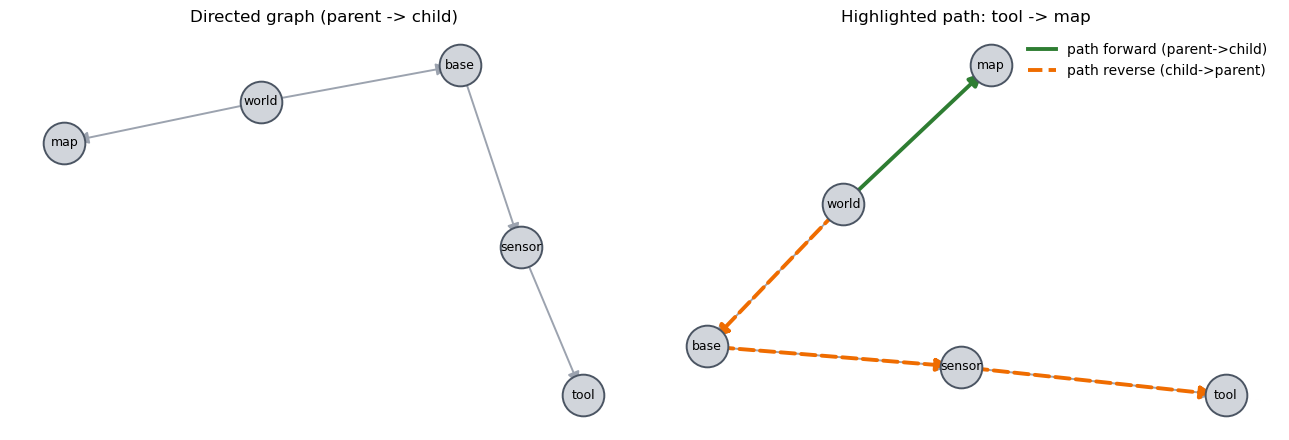

In [3]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('Visualization skipped: matplotlib is not installed (networkx is also required).')

if plt is not None:
    try:
        opts = FrameGraphDrawOptions(layout='spring', include_legend=True)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        draw_frame_graph(graph=graph, opts=opts, ax=axes[0])
        axes[0].set_title('Directed graph (parent -> child)')

        draw_frame_graph(graph=graph, src='tool', dst='map', opts=opts, ax=axes[1])
        axes[1].set_title('Highlighted path: tool -> map')

        plt.tight_layout()
        plt.show()
    except ImportError as exc:
        print(f'Visualization skipped: {exc}')


## Shared typed payloads and edge resolvers

All typed payloads share the same batch/sequence layout so path operations can align them consistently.


In [4]:
payload = build_framegraph_spatial_payloads(
    graph=graph,
    world=world,
    base=base,
    sensor=sensor,
    tool=tool,
    map_frame=map_frame,
)

position = payload['position']
rotation = payload['rotation']
pose = payload['pose']
linear_velocity = payload['linear_velocity']
angular_velocity = payload['angular_velocity']
velocity = payload['velocity']
linear_acceleration = payload['linear_acceleration']
angular_acceleration = payload['angular_acceleration']
acceleration = payload['acceleration']
path_opts = payload['path_opts']
edge_rotation_fn = payload['edge_rotation_fn']
edge_pose_fn = payload['edge_pose_fn']

payload['summary']


{'trials': ['trial_0', 'trial_1'], 'samples': 5, 'time_range_s': (0.0, 1.0)}

## Position: `to_frame` vs `express_in`

`to_frame` changes the parent/child relationship. `express_in` changes the coordinate basis used to write components.


#### Position frame operations

,quantity,type,frames,dims
0,source,Position,"(tool, tip)","{'trial': 2, 'sample': 5, 'axis': 3}"
1,"to_frame(""world"")",Position,"(world, tip)","{'trial': 2, 'sample': 5, 'axis': 3}"
2,"express_in(""map"")",Position,"(tool, tip)","{'trial': 2, 'sample': 5, 'axis': 3}"
3,as_delta(),Position,"(tool, tip)","{'trial': 2, 'sample': 5, 'axis': 3}"


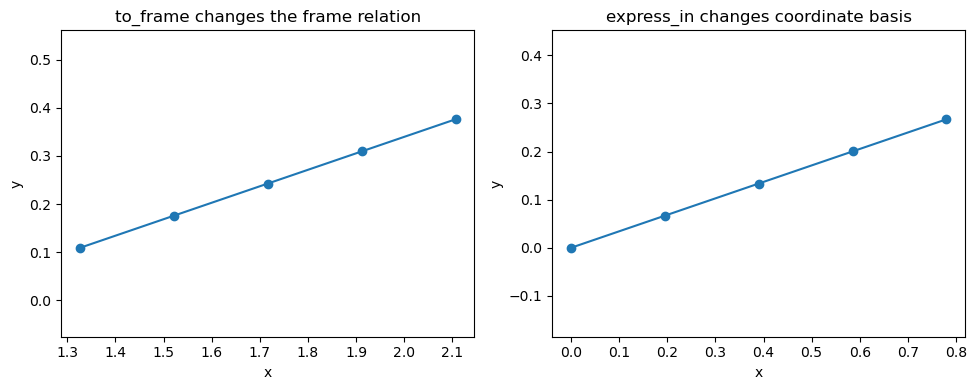

In [5]:
position_world = position.to_frame('world', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)
position_map_basis = position.express_in('map', edge_rotation_fn=edge_rotation_fn, opts=path_opts, validate=True)
position_delta = position.as_delta(validate=True)

display_result(
    'Position frame operations',
    pd.DataFrame(
        [
            {'quantity': 'source', 'type': type(position).__name__, 'frames': frame_ids(position), 'dims': dict(position.as_dataset().sizes)},
            {'quantity': 'to_frame("world")', 'type': type(position_world).__name__, 'frames': frame_ids(position_world), 'dims': dict(position_world.as_dataset().sizes)},
            {'quantity': 'express_in("map")', 'type': type(position_map_basis).__name__, 'frames': frame_ids(position_map_basis), 'dims': dict(position_map_basis.as_dataset().sizes)},
            {'quantity': 'as_delta()', 'type': type(position_delta).__name__, 'frames': frame_ids(position_delta), 'dims': dict(position_delta.as_dataset().sizes)},
        ]
    ),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, obj, title in [
    (axes[0], position_world, 'to_frame changes the frame relation'),
    (axes[1], position_map_basis, 'express_in changes coordinate basis'),
]:
    ds = obj.as_dataset()
    var_name = next(iter(ds.data_vars))
    path = ds[var_name].sel(trial='trial_0')
    ax.plot(path.sel(axis='x'), path.sel(axis='y'), marker='o')
    ax.set(title=title, xlabel='x', ylabel='y')
    ax.axis('equal')
fig.tight_layout()


## Rotation: representation and path transform

Rotation operations preserve sequence/batch roles while changing representation, solving paths, or expressing basis.


In [6]:
rotation_matrix = rotation.as_matrix(validate=True)
rotation_quat = rotation_matrix.as_quat(validate=True)
rotation_path = Rotation.solve_path_transform('tool', 'world', edge_rotation_fn=edge_rotation_fn, opts=path_opts, validate=True)
position_in_tip = frame_retag(position, parent='tip', child='probe', validate=True)
rotated_position = rotation.apply(position_in_tip, validate=True)
rotation_map_basis = rotation.express_in('map', edge_rotation_fn=edge_rotation_fn, opts=path_opts, validate=True)

display(
    pd.DataFrame(
        [
            {'result': 'rotation.as_matrix()', 'type': type(rotation_matrix).__name__, 'dims': dict(rotation_matrix.as_dataset().sizes)},
            {'result': 'as_quat()', 'type': type(rotation_quat).__name__, 'dims': dict(rotation_quat.as_dataset().sizes)},
            {'result': 'solve_path_transform()', 'type': type(rotation_path).__name__, 'frames': frame_ids(rotation_path)},
            {'result': 'rotation.apply(position)', 'type': type(rotated_position).__name__, 'frames': frame_ids(rotated_position)},
            {'result': 'express_in(map)', 'type': type(rotation_map_basis).__name__, 'frames': frame_ids(rotation_map_basis)},
        ]
    )
)


,result,type,dims,frames
0,rotation.as_matrix(),Rotation,"{'trial': 2, 'sample': 5, 'row': 3, 'col': 3}",NaN
1,as_quat(),Rotation,"{'trial': 2, 'sample': 5, 'quat': 4}",NaN
2,solve_path_transform(),Rotation,NaN,"(world, tool)"
3,rotation.apply(position),Position,NaN,"(tool, probe)"
4,express_in(map),Rotation,NaN,"(tool, tip)"


## Pose: path composition and apply

Pose transforms carry both rotation and translation, so they can move positions through a frame graph.


In [7]:
pose_components = pose.as_components(validate=True)
pose_matrix = pose.as_matrix(validate=True)
pose_roundtrip = Pose.from_matrix(pose_matrix, validate=True)
pose_path = Pose.solve_path_transform('tool', 'world', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)
# Notice that .apply() automatically checked the FrameGraph and aligned frame semantics before applying the pose.
position_in_tip_for_pose = frame_retag(position, parent='tip', child='probe_pose', validate=True)
pose_applied_position = pose.apply(position_in_tip_for_pose, validate=True)
pose_map_basis = pose.express_in('map', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)

pos_part, rot_part = pose.decompose(validate=True)

display(
    pd.DataFrame(
        [
            {'result': 'pose.as_components()', 'type': type(pose_components).__name__, 'dims': dict(pose_components.as_dataset().sizes)},
            {'result': 'pose.as_matrix()', 'type': type(pose_matrix).__name__, 'dims': dict(pose_matrix.as_dataset().sizes)},
            {'result': 'Pose.from_matrix()', 'type': type(pose_roundtrip).__name__, 'frames': frame_ids(pose_roundtrip)},
            {'result': 'solve_path_transform()', 'type': type(pose_path).__name__, 'frames': frame_ids(pose_path)},
            {'result': 'pose.apply(position)', 'type': type(pose_applied_position).__name__, 'frames': frame_ids(pose_applied_position)},
            {'result': 'pose.express_in(map)', 'type': type(pose_map_basis).__name__, 'frames': frame_ids(pose_map_basis)},
            {'result': 'pose.decompose() position', 'type': type(pos_part).__name__, 'frames': frame_ids(pos_part)},
            {'result': 'pose.decompose() rotation', 'type': type(rot_part).__name__, 'frames': frame_ids(rot_part)},
        ]
    )
)


,result,type,dims,frames
0,pose.as_components(),Pose,"{'trial': 2, 'sample': 5, 'axis': 3, 'quat': 4}",NaN
1,pose.as_matrix(),Pose,"{'trial': 2, 'sample': 5, 'row': 4, 'col': 4}",NaN
2,Pose.from_matrix(),Pose,NaN,"(tool, tip)"
3,solve_path_transform(),Pose,NaN,"(world, tool)"
4,pose.apply(position),Position,NaN,"(tool, probe_pose)"
5,pose.express_in(map),Pose,NaN,"(tool, tip)"
6,pose.decompose() position,Position,NaN,"(tool, tip)"
7,pose.decompose() rotation,Rotation,NaN,"(tool, tip)"


## Velocity family

Velocity transforms are frame-sensitive and may require kinematic support metadata in addition to static geometry.


In [8]:
velocity_v6 = velocity.as_vector6(validate=True)
velocity_components = velocity_v6.as_components(validate=True)

linear_velocity_world = linear_velocity.to_frame('world', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)
angular_velocity_world = angular_velocity.to_frame('world', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)
velocity_world = velocity.to_frame('world', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)

linear_velocity_map_basis = linear_velocity.express_in('map', edge_rotation_fn=edge_rotation_fn, opts=path_opts, validate=True)
angular_velocity_map_basis = angular_velocity.express_in('map', edge_rotation_fn=edge_rotation_fn, opts=path_opts, validate=True)
velocity_map_basis = velocity.express_in('map', edge_rotation_fn=edge_rotation_fn, opts=path_opts, validate=True)

display(
    pd.DataFrame(
        [
            {'result': 'velocity.as_vector6()', 'type': type(velocity_v6).__name__, 'dims': dict(velocity_v6.as_dataset().sizes)},
            {'result': 'as_components()', 'type': type(velocity_components).__name__, 'dims': dict(velocity_components.as_dataset().sizes)},
            {'result': 'linear.to_frame(world)', 'type': type(linear_velocity_world).__name__, 'frames': frame_ids(linear_velocity_world)},
            {'result': 'angular.to_frame(world)', 'type': type(angular_velocity_world).__name__, 'frames': frame_ids(angular_velocity_world)},
            {'result': 'combined.to_frame(world)', 'type': type(velocity_world).__name__, 'frames': frame_ids(velocity_world)},
            {'result': 'linear.express_in(map)', 'type': type(linear_velocity_map_basis).__name__, 'frames': frame_ids(linear_velocity_map_basis)},
            {'result': 'angular.express_in(map)', 'type': type(angular_velocity_map_basis).__name__, 'frames': frame_ids(angular_velocity_map_basis)},
            {'result': 'combined.express_in(map)', 'type': type(velocity_map_basis).__name__, 'frames': frame_ids(velocity_map_basis)},
        ]
    )
)


,result,type,dims,frames
0,velocity.as_vector6(),Velocity,"{'trial': 2, 'sample': 5, 'velocity_axis': 6}",NaN
1,as_components(),Velocity,"{'trial': 2, 'sample': 5, 'linear_axis': 3, 'a...",NaN
2,linear.to_frame(world),LinearVelocity,NaN,"(world, tip)"
3,angular.to_frame(world),AngularVelocity,NaN,"(world, tip)"
4,combined.to_frame(world),Velocity,NaN,"(world, tip)"
5,linear.express_in(map),LinearVelocity,NaN,"(tool, tip)"
6,angular.express_in(map),AngularVelocity,NaN,"(tool, tip)"
7,combined.express_in(map),Velocity,NaN,"(tool, tip)"


## Acceleration family

Acceleration has similar frame-sensitivity, with even stronger assumptions about support and inertial status.


In [9]:
acceleration_v6 = acceleration.as_vector6(validate=True)
acceleration_components = acceleration_v6.as_components(validate=True)

linear_acc_world = linear_acceleration.to_frame('world', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)
angular_acc_world = angular_acceleration.to_frame('world', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)
acc_world = acceleration.to_frame('world', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)

linear_acc_map_basis = linear_acceleration.express_in('map', edge_rotation_fn=edge_rotation_fn, opts=path_opts, validate=True)
angular_acc_map_basis = angular_acceleration.express_in('map', edge_rotation_fn=edge_rotation_fn, opts=path_opts, validate=True)
acc_map_basis = acceleration.express_in('map', edge_rotation_fn=edge_rotation_fn, opts=path_opts, validate=True)

display(
    pd.DataFrame(
        [
            {'result': 'acceleration.as_vector6()', 'type': type(acceleration_v6).__name__, 'dims': dict(acceleration_v6.as_dataset().sizes)},
            {'result': 'as_components()', 'type': type(acceleration_components).__name__, 'dims': dict(acceleration_components.as_dataset().sizes)},
            {'result': 'linear.to_frame(world)', 'type': type(linear_acc_world).__name__, 'frames': frame_ids(linear_acc_world)},
            {'result': 'angular.to_frame(world)', 'type': type(angular_acc_world).__name__, 'frames': frame_ids(angular_acc_world)},
            {'result': 'combined.to_frame(world)', 'type': type(acc_world).__name__, 'frames': frame_ids(acc_world)},
            {'result': 'linear.express_in(map)', 'type': type(linear_acc_map_basis).__name__, 'frames': frame_ids(linear_acc_map_basis)},
            {'result': 'angular.express_in(map)', 'type': type(angular_acc_map_basis).__name__, 'frames': frame_ids(angular_acc_map_basis)},
            {'result': 'combined.express_in(map)', 'type': type(acc_map_basis).__name__, 'frames': frame_ids(acc_map_basis)},
        ]
    )
)


,result,type,dims,frames
0,acceleration.as_vector6(),Acceleration,"{'trial': 2, 'sample': 5, 'acceleration_axis': 6}",NaN
1,as_components(),Acceleration,"{'trial': 2, 'sample': 5, 'linear_axis': 3, 'a...",NaN
2,linear.to_frame(world),LinearAcceleration,NaN,"(world, tip)"
3,angular.to_frame(world),AngularAcceleration,NaN,"(world, tip)"
4,combined.to_frame(world),Acceleration,NaN,"(world, tip)"
5,linear.express_in(map),LinearAcceleration,NaN,"(tool, tip)"
6,angular.express_in(map),AngularAcceleration,NaN,"(tool, tip)"
7,combined.express_in(map),Acceleration,NaN,"(tool, tip)"


## Kinematic support metadata

Edge motion class and frame inertial status are metadata TAL can use to decide which kinematic transforms are supported.


In [10]:
edge_motion_summary = {
    (child.id, parent.id): get_edge_motion_class(child, parent)
    for child, parent in [(base, world), (sensor, base), (tool, sensor), (map_frame, world)]
}
frame_inertial_summary = {
    frame.id: get_frame_inertial_status(frame)
    for frame in (world, base, sensor, tool, map_frame)
}

velocity_world_check = velocity.to_frame('world', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)
display(velocity_world_check.as_dataset())
{'edge_motion_class': edge_motion_summary, 'frame_inertial_status': frame_inertial_summary}


<xarray.Dataset> Size: 600B
Dimensions:           (trial: 2, sample: 5, linear_axis: 3, angular_axis: 3)
Coordinates:
  * trial             (trial) object 16B 'trial_0' 'trial_1'
  * sample            (sample) int64 40B 0 1 2 3 4
  * linear_axis       (linear_axis) <U1 12B 'x' 'y' 'z'
  * angular_axis      (angular_axis) <U1 12B 'x' 'y' 'z'
    time_s            (sample) float64 40B 0.0 0.25 0.5 0.75 1.0
Data variables:
    linear_velocity   (trial, sample, linear_axis) float64 240B 0.3986 ... 0.0
    angular_velocity  (trial, sample, angular_axis) float64 240B 0.0 ... 0.27
Attributes:
    tal:      {'version': 1, 'core': {'roles': {'batch_dims': ['trial'], 'cor...

{'edge_motion_class': {('base', 'world'): 'static',
  ('sensor', 'base'): 'static',
  ('tool', 'sensor'): 'static',
  ('map', 'world'): 'static'},
 'frame_inertial_status': {'world': 'inertial',
  'base': 'inertial',
  'sensor': 'inertial',
  'tool': 'inertial',
  'map': 'inertial'}}

## Coverage matrix

This is a compact summary that the notebook exercised each spatial family.


In [11]:
coverage = {
    'Position': {
        'constructed': isinstance(position, Position),
        'frame_transform': isinstance(position_world, Position),
        'basis_expression': isinstance(position_map_basis, Position),
    },
    'Rotation': {
        'constructed': isinstance(rotation, Rotation),
        'path_solve': isinstance(rotation_path, Rotation),
        'basis_expression': isinstance(rotation_map_basis, Rotation),
    },
    'Pose': {
        'constructed': isinstance(pose, Pose),
        'path_solve': isinstance(pose_path, Pose),
        'basis_expression': isinstance(pose_map_basis, Pose),
    },
    'LinearVelocity': {
        'constructed': isinstance(linear_velocity, LinearVelocity),
        'frame_transform': isinstance(linear_velocity_world, LinearVelocity),
        'basis_expression': isinstance(linear_velocity_map_basis, LinearVelocity),
    },
    'AngularVelocity': {
        'constructed': isinstance(angular_velocity, AngularVelocity),
        'frame_transform': isinstance(angular_velocity_world, AngularVelocity),
        'basis_expression': isinstance(angular_velocity_map_basis, AngularVelocity),
    },
    'Velocity': {
        'constructed': isinstance(velocity, Velocity),
        'frame_transform': isinstance(velocity_world, Velocity),
        'basis_expression': isinstance(velocity_map_basis, Velocity),
    },
    'LinearAcceleration': {
        'constructed': isinstance(linear_acceleration, LinearAcceleration),
        'frame_transform': isinstance(linear_acc_world, LinearAcceleration),
        'basis_expression': isinstance(linear_acc_map_basis, LinearAcceleration),
    },
    'AngularAcceleration': {
        'constructed': isinstance(angular_acceleration, AngularAcceleration),
        'frame_transform': isinstance(angular_acc_world, AngularAcceleration),
        'basis_expression': isinstance(angular_acc_map_basis, AngularAcceleration),
    },
    'Acceleration': {
        'constructed': isinstance(acceleration, Acceleration),
        'frame_transform': isinstance(acc_world, Acceleration),
        'basis_expression': isinstance(acc_map_basis, Acceleration),
    },
}

display(pd.DataFrame(coverage).T)


,constructed,frame_transform,basis_expression,path_solve
Position,True,True,True,NaN
Rotation,True,NaN,True,True
Pose,True,NaN,True,True
LinearVelocity,True,True,True,NaN
AngularVelocity,True,True,True,NaN
Velocity,True,True,True,NaN
LinearAcceleration,True,True,True,NaN
AngularAcceleration,True,True,True,NaN
Acceleration,True,True,True,NaN


## Fail-closed boundaries

Unknown frames and missing paths should fail deterministically instead of producing ambiguous transforms.


In [12]:
try:
    _ = position.to_frame('missing_frame', edge_pose_fn=edge_pose_fn, opts=path_opts, validate=True)
except Exception as exc:
    print('expected failure (unknown frame):', type(exc).__name__, str(exc))

try:
    _ = Rotation.solve_path_transform('tool', 'missing_frame', edge_rotation_fn=edge_rotation_fn, opts=path_opts, validate=True)
except Exception as exc:
    print('expected failure (path solve unknown dst):', type(exc).__name__, str(exc))


expected failure (unknown frame): ValueError spatial.position.to_frame: dst frame 'missing_frame' is not registered in graph.
expected failure (path solve unknown dst): ValueError spatial.rotation.solve_path_transform: dst frame 'missing_frame' is not registered in graph.


## Takeaways

- `to_frame` and `express_in` answer different questions.
- Resolver functions make transform data explicit.
- Kinematic support metadata keeps velocity/acceleration transforms honest.

**Exercise:** add another frame between `sensor` and `tool`, then update the resolver maps.
